<div style="background-color:#EFF5FF; padding:22px; border-radius:10px; border-left:8px solid #0047AB;">
<h1 style="margin-bottom:0;"><b>Machine Learning II</b></h1>
<h3><b>Customer Segmentation — Clustering</b></h3>
<p style="font-size:15px; margin-top:14px;">
This notebook identifies natural customer segments using <b>K-Means</b>,
<b>Hierarchical Clustering (Ward)</b>, <b>DBSCAN</b> and <b>Mean Shift</b>.
The number of clusters is determined by the elbow and silhouette curves — not assumed upfront.
The scaler is chosen based on quantitative evidence before running any model.<br><br>
Clustering is performed in the <b>original scaled feature space</b> — no PCA.
PCA and UMAP are used only for 2D visualisation after models are trained, so
every centroid remains readable as a real customer behaviour profile.<br><br>
All reusable logic lives in <code>Clustering.py</code>.
</p></div>

<div style="background-color:#EFF5FF; padding:18px; border-radius:10px; border-left:8px solid #0047AB;">
<h2 style="margin-top:0;"><b>Index</b></h2>
<ol>
<li>Imports &amp; Data Loading</li>
<li>Scaler Comparison</li>
<li>K-Means: Elbow &amp; Silhouette</li>
<li>Final K-Means Model</li>
<li>K-Means Visualisations: Silhouette · PCA · UMAP</li>
<li>Hierarchical Clustering (Ward on Centroids)</li>
<li>Hierarchical Visualisations: Silhouette · PCA · UMAP</li>
<li>DBSCAN</li>
<li>Mean Shift</li>
<li>Model Comparison &amp; Final Choice</li>
<li>Assigning Outliers to the Final Model</li>
<li>Export</li>
</ol></div>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>1. Imports &amp; Data Loading</b></h3></div>

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import umap
import importlib
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances_argmin_min
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

from Clustering import (run_kmeans, elbow_and_silhouette, visualize_umap,
                         visualize_pca, silhouette_plot, read_newdata, read_outliers,
                         run_dbscan, run_meanshift, compare_models,
                         compare_scalers, plot_scaler_comparison)
import Clustering as clu
importlib.reload(clu)

warnings.filterwarnings("ignore")

In [2]:
info_clustering = read_newdata()
info_clustering.set_index("customer_id", inplace=True)
print(info_clustering.shape)
info_clustering.head()

Dataset loaded: 33,038 customers | 25 features
(33038, 24)


,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,customer_loyalty_flag,latitude,longitude,typical_hour_sin,typical_hour_cos,customer_age,...,pct_spend_groceries,pct_spend_vegetables,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,log_total_spend
customer_id,,,,,,,,,,,,,,,,,,,,,
3,1,3,189,0.631599,1,38.794428,-9.215739,0.151764,-4.063504e-01,56.0,...,0.631038,0.020065,0.017375,0.009521,0.001506,0.011458,0.029693,0.020656,0.258687,9.830433
4,0,2,130,0.149890,1,38.751711,-9.179611,-0.148236,-7.395953e-01,50.0,...,0.676815,0.099442,0.026343,0.004695,0.002125,0.000741,0.092918,0.032867,0.064054,9.915120
5,0,2,81,0.069126,0,38.780678,-9.160656,0.258819,-9.659258e-01,54.0,...,0.797929,0.035694,0.006496,0.007589,0.081356,0.017557,0.032607,0.014277,0.006496,9.651816
7,2,1,92,0.253609,1,38.739548,-9.148679,-1.000000,-1.665335e-16,43.0,...,0.501137,0.005618,0.050629,0.075776,0.065008,0.072432,0.032437,0.012306,0.184658,9.612667
8,2,1,6,0.186569,1,38.733071,-9.188188,-0.965926,-2.588190e-01,56.0,...,0.385826,0.015959,0.024862,0.030154,0.044853,0.042627,0.012473,0.018521,0.424726,10.077955


In [3]:
_cols = set(info_clustering.columns)

EXCLUDED_COLS = [c for c in ["customer_gender", "latitude", "longitude",
                              "has_loyalty_card"] if c in _cols]

# Binary (0/1) — kept unscaled
BINARY_COLS = [c for c in ["customer_loyalty_flag", "is_male"] if c in _cols]

# education_level encoded as years (12/15/17/22) — always StandardScaler
# to prevent it dominating the distance space with MinMaxScaler
ORDINAL_COLS = [c for c in ["education_level"] if c in _cols]

print(f"Excluded : {EXCLUDED_COLS}")
print(f"Binary   : {BINARY_COLS}")
print(f"Ordinal  : {ORDINAL_COLS}")
print(f"Features for clustering: {info_clustering.shape[1] - len(EXCLUDED_COLS)} columns")

Excluded : ['latitude', 'longitude']
Binary   : ['customer_loyalty_flag', 'is_male']
Ordinal  : ['education_level']
Features for clustering: 22 columns


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>2. Scaler Comparison</b></h3></div>

<div style="background-color:#F9FCFF; padding:16px; border-radius:10px;">Before choosing a model we compare three scalers quantitatively. Clustering is in the <b>original scaled feature space</b> — no PCA — so cluster profiles remain interpretable as real customer behaviours.</div>

In [4]:
scaler_comparison = compare_scalers(
    info_clustering,
    exclude_cols         = EXCLUDED_COLS,
    binary_cols          = BINARY_COLS,
    ordinal_cols         = ORDINAL_COLS,
    k_values             = (4, 5, 6),
    random_state         = 42,
    include_hierarchical = True,
)
scaler_comparison

,Algorithm,Scaler,k,Silhouette
0,K-Means,MinMax,4,0.2096
1,K-Means,MinMax,5,0.2080
2,Hierarchical (Ward),MinMax,4,0.2069
3,K-Means,MinMax,6,0.2055
4,Hierarchical (Ward),Robust,4,0.2032
5,Hierarchical (Ward),MinMax,5,0.2019
6,Hierarchical (Ward),MinMax,6,0.1962
7,Hierarchical (Ward),Standard,4,0.1709
8,K-Means,Robust,5,0.1566
9,Hierarchical (Ward),Robust,6,0.1497


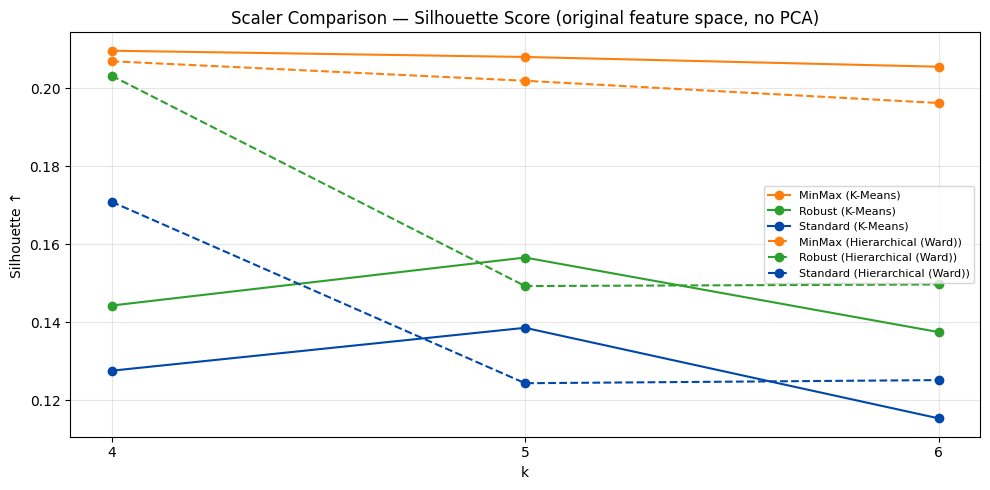

In [5]:
plot_scaler_comparison(scaler_comparison)

In [6]:
# Chosen scalers and k values based on the comparison above
SCALER_KMEANS = "minmax"   # best silhouette for K-Means
BEST_K        = 6

SCALER_HIER   = "robust"   # best silhouette for Hierarchical
BEST_K_HIER   = 5

print(f"K-Means      → scaler = {SCALER_KMEANS.capitalize()},  k = {BEST_K}")
print(f"Hierarchical → scaler = {SCALER_HIER.capitalize()},    k = {BEST_K_HIER}")

K-Means      → scaler = Minmax,  k = 6
Hierarchical → scaler = Robust,    k = 5


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>3. K-Means: Elbow &amp; Silhouette</b></h3></div>

<div style="background-color:#F9FCFF; padding:16px; border-radius:10px;">We test k = 2 to 12 with the chosen scaler (MinMax). The elbow marks where inertia stops dropping sharply; the silhouette peak confirms where clusters are most cohesive and separated. Both curves use the same scaled space as the final model.</div>

K=2: Inertia=50158, Silhouette=0.3156
K=3: Inertia=41955, Silhouette=0.2258
K=4: Inertia=37374, Silhouette=0.2096
K=5: Inertia=34669, Silhouette=0.2080
K=6: Inertia=32268, Silhouette=0.2055
K=7: Inertia=30646, Silhouette=0.2160
K=8: Inertia=29371, Silhouette=0.2025
K=9: Inertia=28504, Silhouette=0.1864
K=10: Inertia=27696, Silhouette=0.1817
K=11: Inertia=27040, Silhouette=0.1840
K=12: Inertia=26526, Silhouette=0.1788


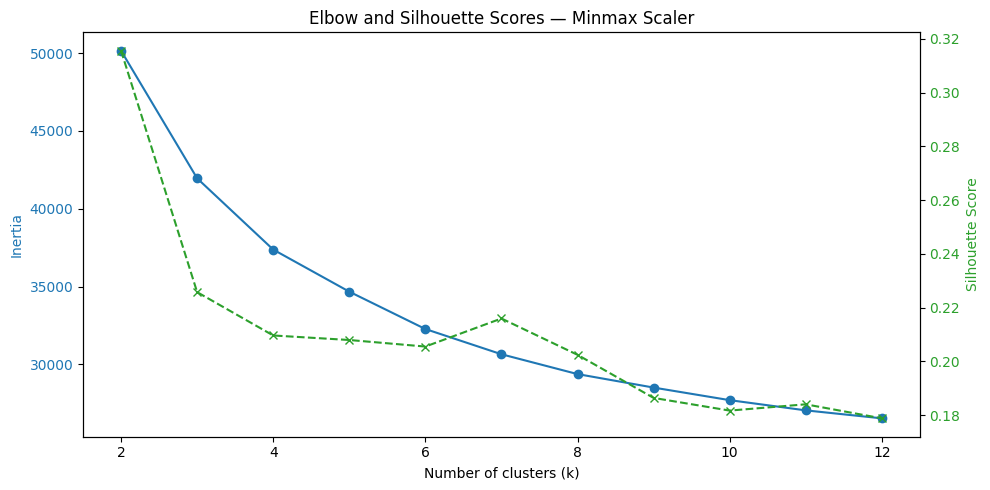

In [7]:
info_clustering_kmeans = info_clustering.copy()

inertias, silhouettes = elbow_and_silhouette(
    info_clustering_kmeans,
    exclude_cols = EXCLUDED_COLS,
    binary_cols  = BINARY_COLS,
    ordinal_cols = ORDINAL_COLS,
    scaler_name  = SCALER_KMEANS,
    max_k        = 12,
)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>4. Final K-Means Model</b></h3></div>

In [8]:
BEST_K=7

In [9]:
labels_km, centroids_km, score_km, X_km_scaled = run_kmeans(
    info_clustering_kmeans,
    k            = BEST_K,
    exclude_cols = EXCLUDED_COLS,
    binary_cols  = BINARY_COLS,
    ordinal_cols = ORDINAL_COLS,
    scaler_name  = SCALER_KMEANS,
    random_state = 42,
)
print(f"Silhouette K-Means k={BEST_K}: {score_km:.4f}")

Silhouette K-Means k=7: 0.2160


In [10]:
info_clustering_kmeans["kmeans_cluster"] = labels_km
print(info_clustering_kmeans["kmeans_cluster"].value_counts().sort_index())

kmeans_cluster
0    3188
1    4863
2    5096
3    6030
4    5828
5    4733
6    3300
Name: count, dtype: int64


In [11]:
feature_cols = [c for c in info_clustering_kmeans.columns
                if c not in EXCLUDED_COLS + ["kmeans_cluster"]]

centroids_df_kmeans = (
    pd.DataFrame(centroids_km, columns=feature_cols)
      .assign(kmeans_cluster=range(BEST_K))
      .set_index("kmeans_cluster")
)
display(centroids_df_kmeans)

,number_complaints,distinct_stores_visited,lifetime_total_distinct_products,percentage_of_products_bought_promotion,customer_loyalty_flag,typical_hour_sin,typical_hour_cos,customer_age,education_level,is_male,...,pct_spend_groceries,pct_spend_vegetables,pct_spend_nonalcohol_drinks,pct_spend_alcohol_drinks,pct_spend_meat,pct_spend_fish,pct_spend_hygiene,pct_spend_petfood,pct_spend_technology,log_total_spend
kmeans_cluster,,,,,,,,,,,,,,,,,,,,,
0,0.990590,2.918130,118.441029,0.461457,1.000000,-0.056743,-0.326375,54.384818,12.000000,1.000000,...,0.630988,0.023556,0.019921,0.029953,0.051787,0.034794,0.030486,0.020052,0.158464,9.822660
1,0.747275,3.319145,173.104257,0.304477,0.934197,0.130563,-0.490195,55.492577,16.047090,1.000000,...,0.672508,0.050845,0.023876,0.025352,0.031840,0.025642,0.049109,0.017892,0.102936,10.003181
2,0.729592,3.360283,164.895408,0.301051,0.880691,0.128403,-0.485964,56.249568,22.000000,0.506672,...,0.671547,0.053141,0.023980,0.024887,0.030150,0.025052,0.050944,0.018246,0.102053,9.968781
3,0.910779,3.023549,142.290547,0.341958,0.000000,0.024472,-0.376942,52.908823,12.155721,0.000000,...,0.632136,0.039730,0.023275,0.035794,0.033816,0.029152,0.040194,0.017877,0.148027,9.877351
4,0.911805,3.010638,142.728723,0.336282,0.000000,0.030456,-0.383226,52.643789,12.155456,1.000000,...,0.634549,0.042343,0.023128,0.035231,0.032974,0.028362,0.040967,0.017920,0.144525,9.879352
5,0.736953,3.313121,166.180858,0.301414,0.932390,0.127669,-0.479104,56.528544,16.061061,0.000000,...,0.667700,0.052564,0.024179,0.025258,0.031791,0.025363,0.051546,0.018492,0.103108,9.969897
6,0.980000,2.880303,116.293939,0.456074,1.000000,-0.065140,-0.313052,54.282606,12.000000,0.000000,...,0.629256,0.023504,0.019890,0.030318,0.050951,0.033630,0.030032,0.019699,0.162719,9.838726


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>5. K-Means Visualisations: Silhouette · PCA · UMAP</b></h3></div>

<div style="background-color:#F9FCFF; padding:16px; border-radius:10px;">Three complementary views to validate cluster quality. PCA and UMAP are <b>visualisation only</b> — clustering was done in the original scaled space. The silhouette plot uses the same scaled matrix as the model, so the average shown matches the score above exactly.</div>

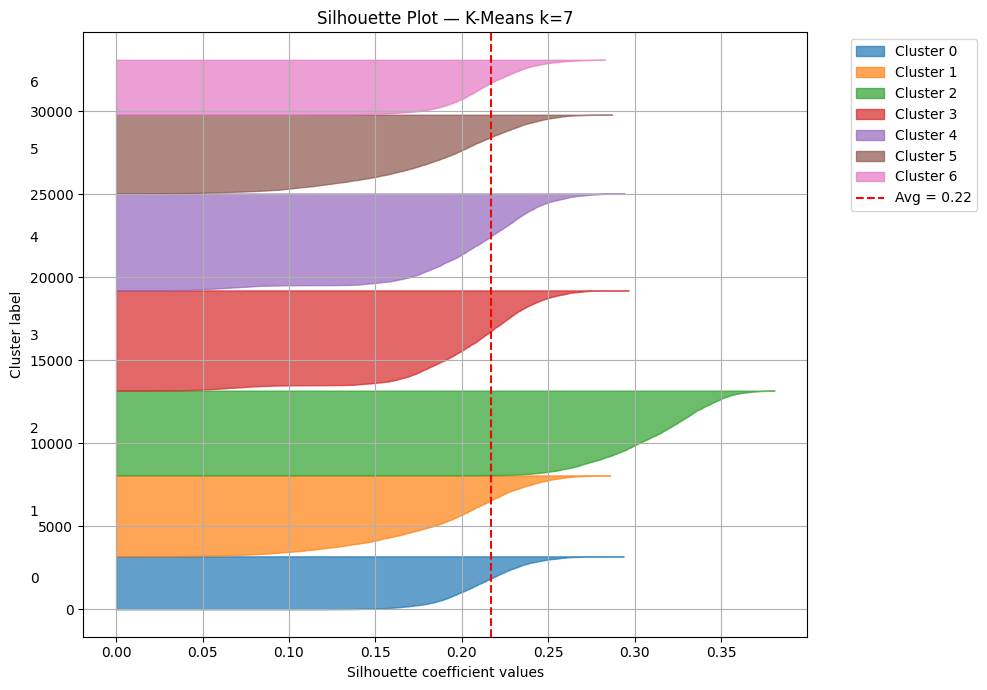

In [12]:
# Silhouette — same X_km_scaled as the model
silhouette_plot(
    X_km_scaled,
    info_clustering_kmeans["kmeans_cluster"].values,
    title=f"Silhouette Plot — K-Means k={BEST_K}"
)

Explained variance (2 components): 56.6%


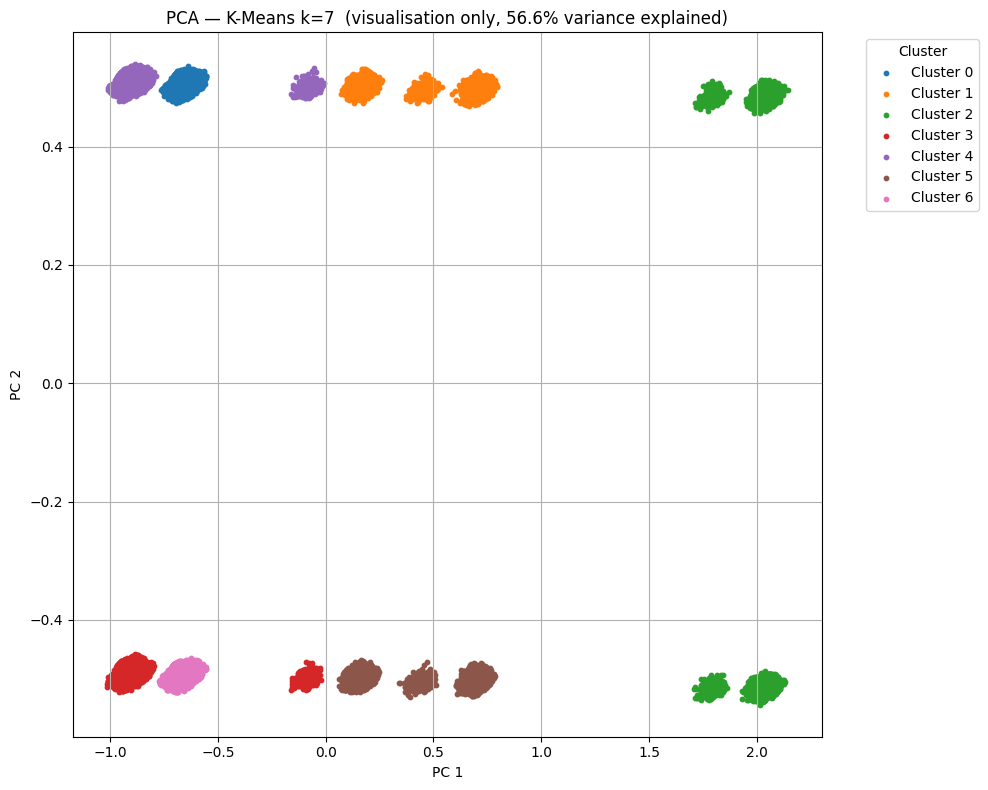

In [13]:
# PCA — visualisation only
pca              = PCA(n_components=2)
pca_embedding_km = pca.fit_transform(X_km_scaled)
var_km           = pca.explained_variance_ratio_.sum()
print(f"Explained variance (2 components): {var_km:.1%}")

visualize_pca(
    pca_embedding_km,
    labels = info_clustering_kmeans["kmeans_cluster"].values,
    title  = f"PCA — K-Means k={BEST_K}  (visualisation only, {var_km:.1%} variance explained)"
)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


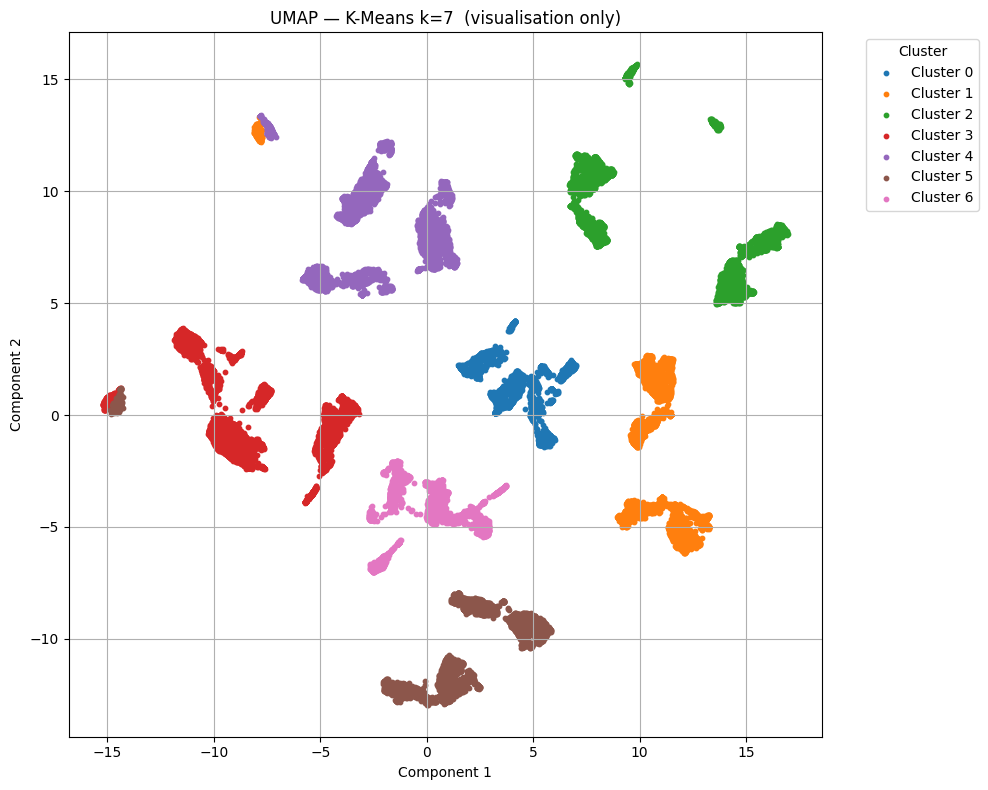

In [14]:
# UMAP — visualisation only
umap_km           = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
umap_embedding_km = umap_km.fit_transform(X_km_scaled)

visualize_umap(
    umap_embedding_km,
    labels = info_clustering_kmeans["kmeans_cluster"].values,
    title  = f"UMAP — K-Means k={BEST_K}  (visualisation only)"
)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>6. Hierarchical Clustering (Ward on Centroids)</b></h3></div>

<div style="background-color:#F9FCFF; padding:16px; border-radius:10px;">We run Ward linkage on 20 K-Means centroids rather than directly on all customers. Running Ward on 33 000 rows requires ~4 GB RAM and produces an unreadable dendrogram. On 20 centroids it is instant and reveals the same macro-structure.</div>

In [15]:
info_clustering_hierarchical = info_clustering.copy()

# Step 1: K-Means k=20 to create dense micro-clusters
labels20, centroids20, sil20, X_hier_scaled = run_kmeans(
    info_clustering_hierarchical,
    k            = 20,
    exclude_cols = EXCLUDED_COLS,
    binary_cols  = BINARY_COLS,
    ordinal_cols = ORDINAL_COLS,
    scaler_name  = SCALER_HIER,
    random_state = 42,
)
print(f"Silhouette k=20 (micro-clusters): {sil20:.4f}")
info_clustering_hierarchical["kmeans20_cluster"] = labels20

Silhouette k=20 (micro-clusters): 0.1150


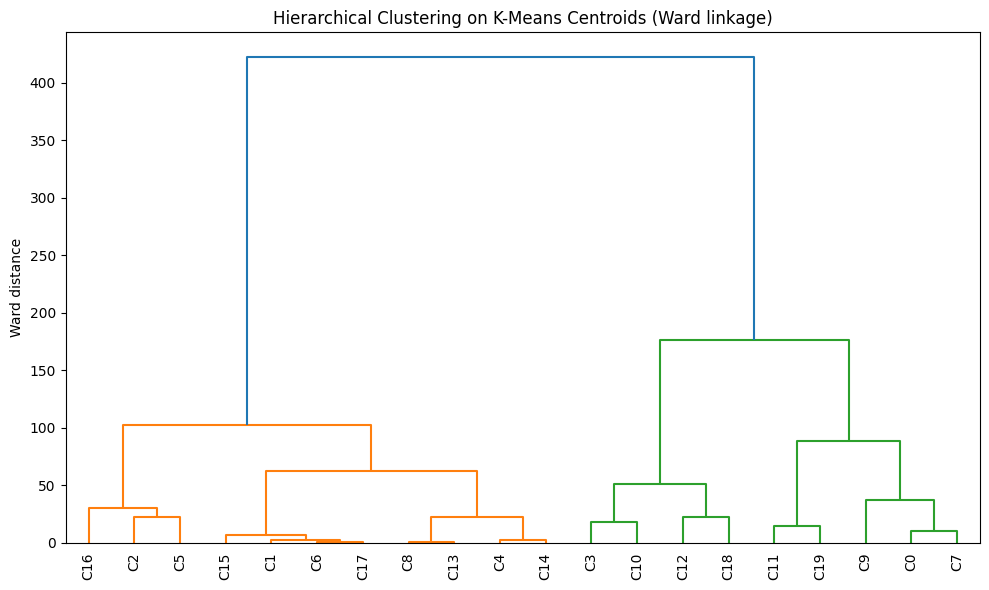

In [16]:
# Step 2: Ward linkage on the 20 centroids
feature_cols_hier = [c for c in info_clustering_hierarchical.columns
                     if c not in EXCLUDED_COLS + ["kmeans20_cluster"]]

centroids_df_hier = pd.DataFrame(centroids20, columns=feature_cols_hier)
centroids_df_hier.index = [f"C{i}" for i in range(20)]

Z = linkage(centroids_df_hier, method="ward")

plt.figure(figsize=(10, 6))
dendrogram(Z, labels=[f"C{i}" for i in range(len(centroids_df_hier))],
           leaf_rotation=90, leaf_font_size=10, color_threshold=None)
plt.title("Hierarchical Clustering on K-Means Centroids (Ward linkage)")
plt.ylabel("Ward distance")
plt.tight_layout()
plt.show()

In [17]:
# Step 3: Cut the dendrogram at the chosen k
macro_labels      = fcluster(Z, t=BEST_K_HIER, criterion="maxclust")
centroid_to_macro = {idx: lab for idx, lab in enumerate(macro_labels)}

info_clustering_hierarchical["macro_cluster"] = (
    info_clustering_hierarchical["kmeans20_cluster"].map(centroid_to_macro))

print("Macro-cluster distribution:")
print(info_clustering_hierarchical["macro_cluster"].value_counts().sort_index())

Macro-cluster distribution:
macro_cluster
1     5592
2    11201
3     8697
4     3132
5     4416
Name: count, dtype: int64


In [18]:
from sklearn.metrics import silhouette_score as _sil
lbl_hier = info_clustering_hierarchical["macro_cluster"].values
sil_hier = _sil(X_hier_scaled, lbl_hier, sample_size=5000, random_state=42)
print(f"Hierarchical k={BEST_K_HIER}: Silhouette = {sil_hier:.4f}")

Hierarchical k=5: Silhouette = 0.0415


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>7. Hierarchical Visualisations: Silhouette · PCA · UMAP</b></h3></div>

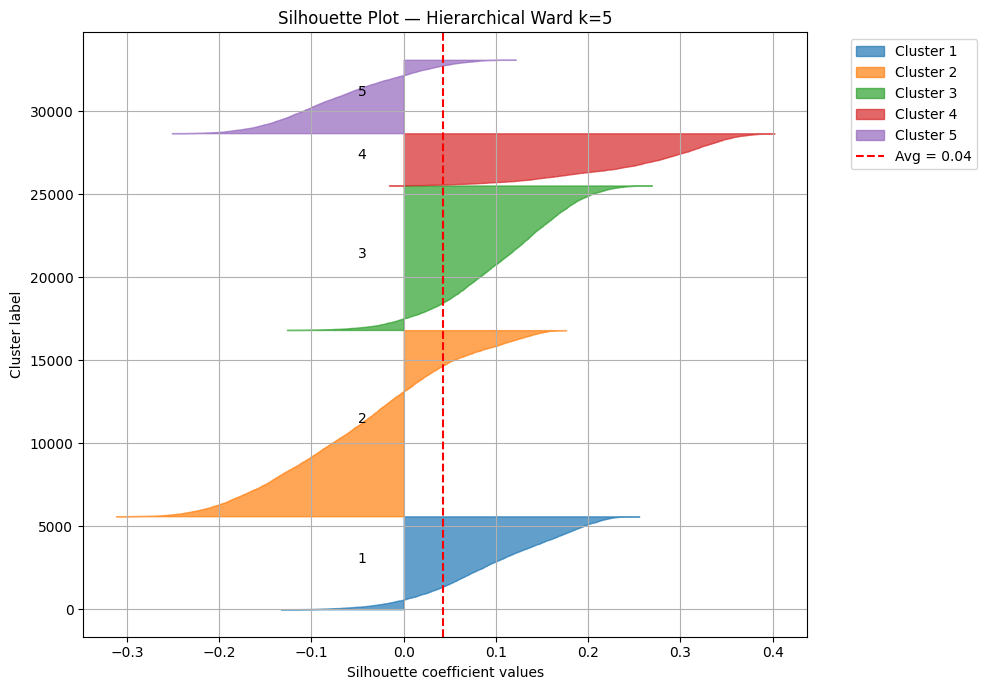

In [19]:
labels_hier = info_clustering_hierarchical["macro_cluster"].values

# Silhouette — same X_hier_scaled as the model
silhouette_plot(
    X_hier_scaled, labels_hier,
    title=f"Silhouette Plot — Hierarchical Ward k={BEST_K_HIER}"
)

Explained variance (2 components): 35.4%


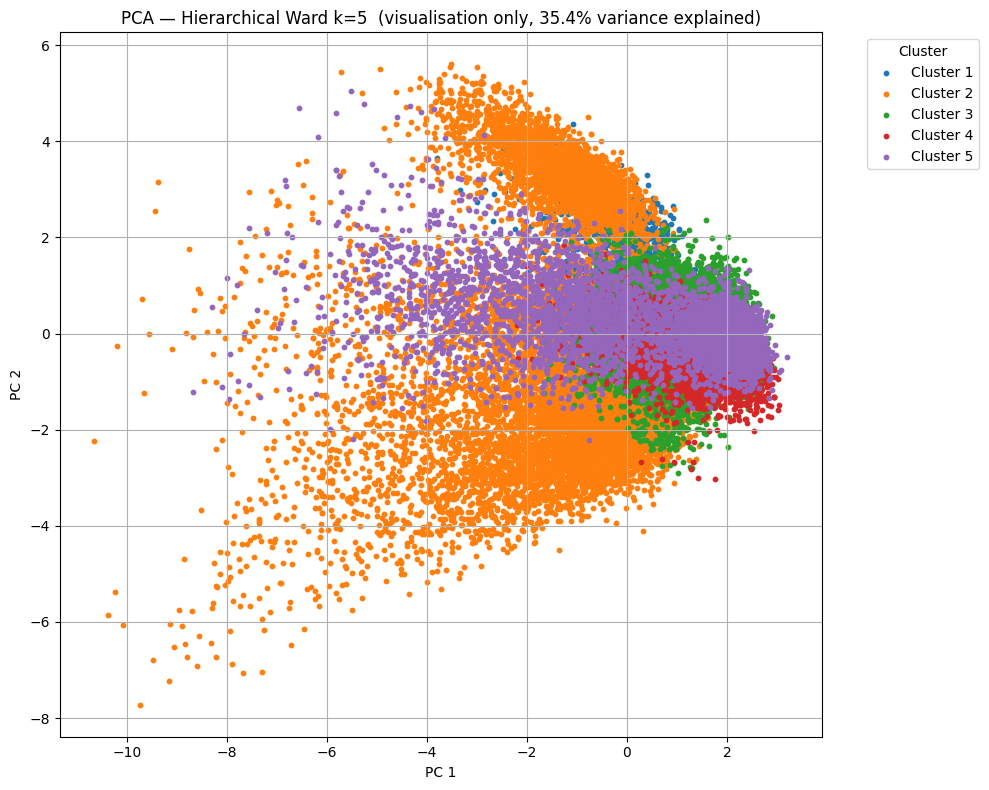

In [20]:
# PCA — visualisation only
pca_hier           = PCA(n_components=2)
pca_embedding_hier = pca_hier.fit_transform(X_hier_scaled)
var_hier           = pca_hier.explained_variance_ratio_.sum()
print(f"Explained variance (2 components): {var_hier:.1%}")

visualize_pca(
    pca_embedding_hier, labels=labels_hier,
    title=f"PCA — Hierarchical Ward k={BEST_K_HIER}  (visualisation only, {var_hier:.1%} variance explained)"
)

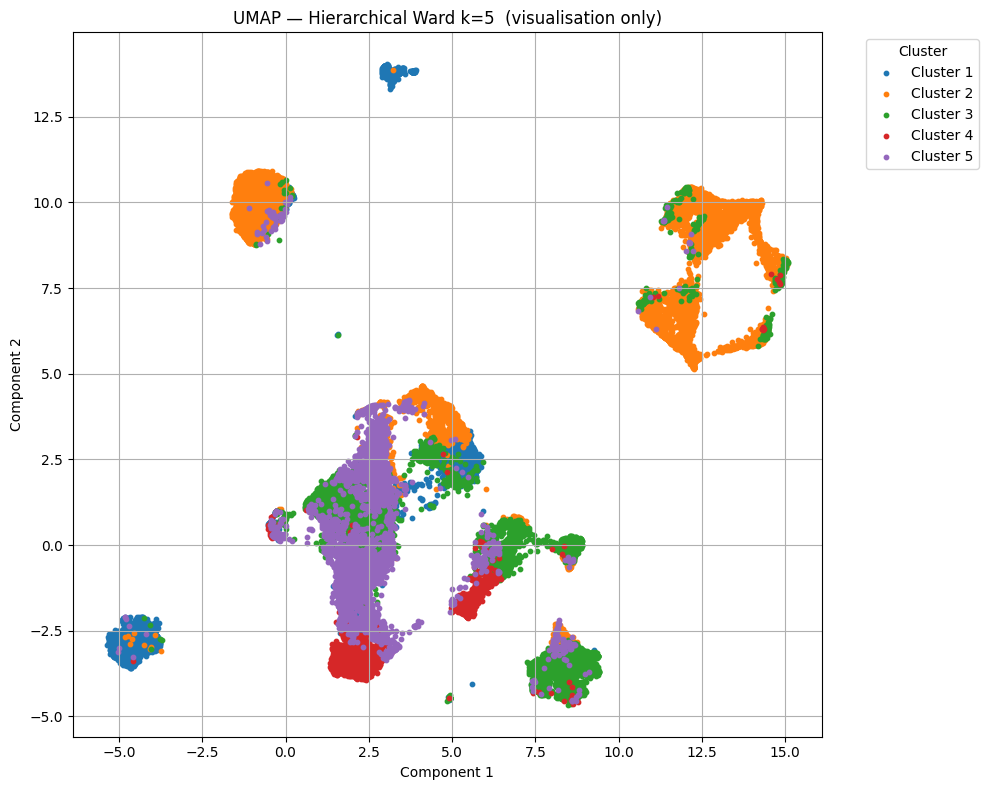

In [21]:
# UMAP — visualisation only
umap_hier           = umap.UMAP(n_neighbors=15, min_dist=0.05, random_state=42)
umap_embedding_hier = umap_hier.fit_transform(X_hier_scaled)

visualize_umap(
    umap_embedding_hier, labels=labels_hier,
    title=f"UMAP — Hierarchical Ward k={BEST_K_HIER}  (visualisation only)"
)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>8. DBSCAN</b></h3></div>

<div style="background-color:#F9FCFF; padding:16px; border-radius:10px;">DBSCAN finds clusters as dense regions separated by sparse areas. It does not require a fixed k — the number of clusters emerges from the data. Points that don't belong to any dense region are labelled as noise (−1). We explore eps values to find the configuration with the best silhouette and a manageable noise rate.</div>

In [22]:
X_db = info_clustering.drop(columns=EXCLUDED_COLS, errors="ignore")

dbscan_results = clu.explore_dbscan(X_db, eps_values=np.arange(0.5, 5.0, 0.5),
                                     min_samples=10)
dbscan_results

,eps,n_clusters,noise_pct,silhouette
0,4.5,99,44.8,-0.6609
1,0.5,0,100.0,NaN
2,1.0,0,100.0,NaN
3,1.5,8,99.5,NaN
4,2.0,5,99.0,NaN
5,2.5,23,96.2,NaN
6,3.0,10,92.4,NaN
7,3.5,62,87.3,NaN
8,4.0,122,68.6,NaN


In [23]:
best_eps = dbscan_results.iloc[0]["eps"]
labels_db, score_db, noise_pct = run_dbscan(X_db, eps=best_eps, min_samples=10)

print(f"DBSCAN eps={best_eps}: Silhouette = {score_db:.4f} | Noise = {noise_pct:.1f}%")
print(pd.Series(labels_db).value_counts().sort_index())

DBSCAN eps=4.5: Silhouette = -0.6609 | Noise = 44.8%
-1     14802
 0     16356
 1        43
 2       158
 3        53
       ...  
 94       12
 95        8
 96        5
 97       11
 98       10
Name: count, Length: 100, dtype: int64


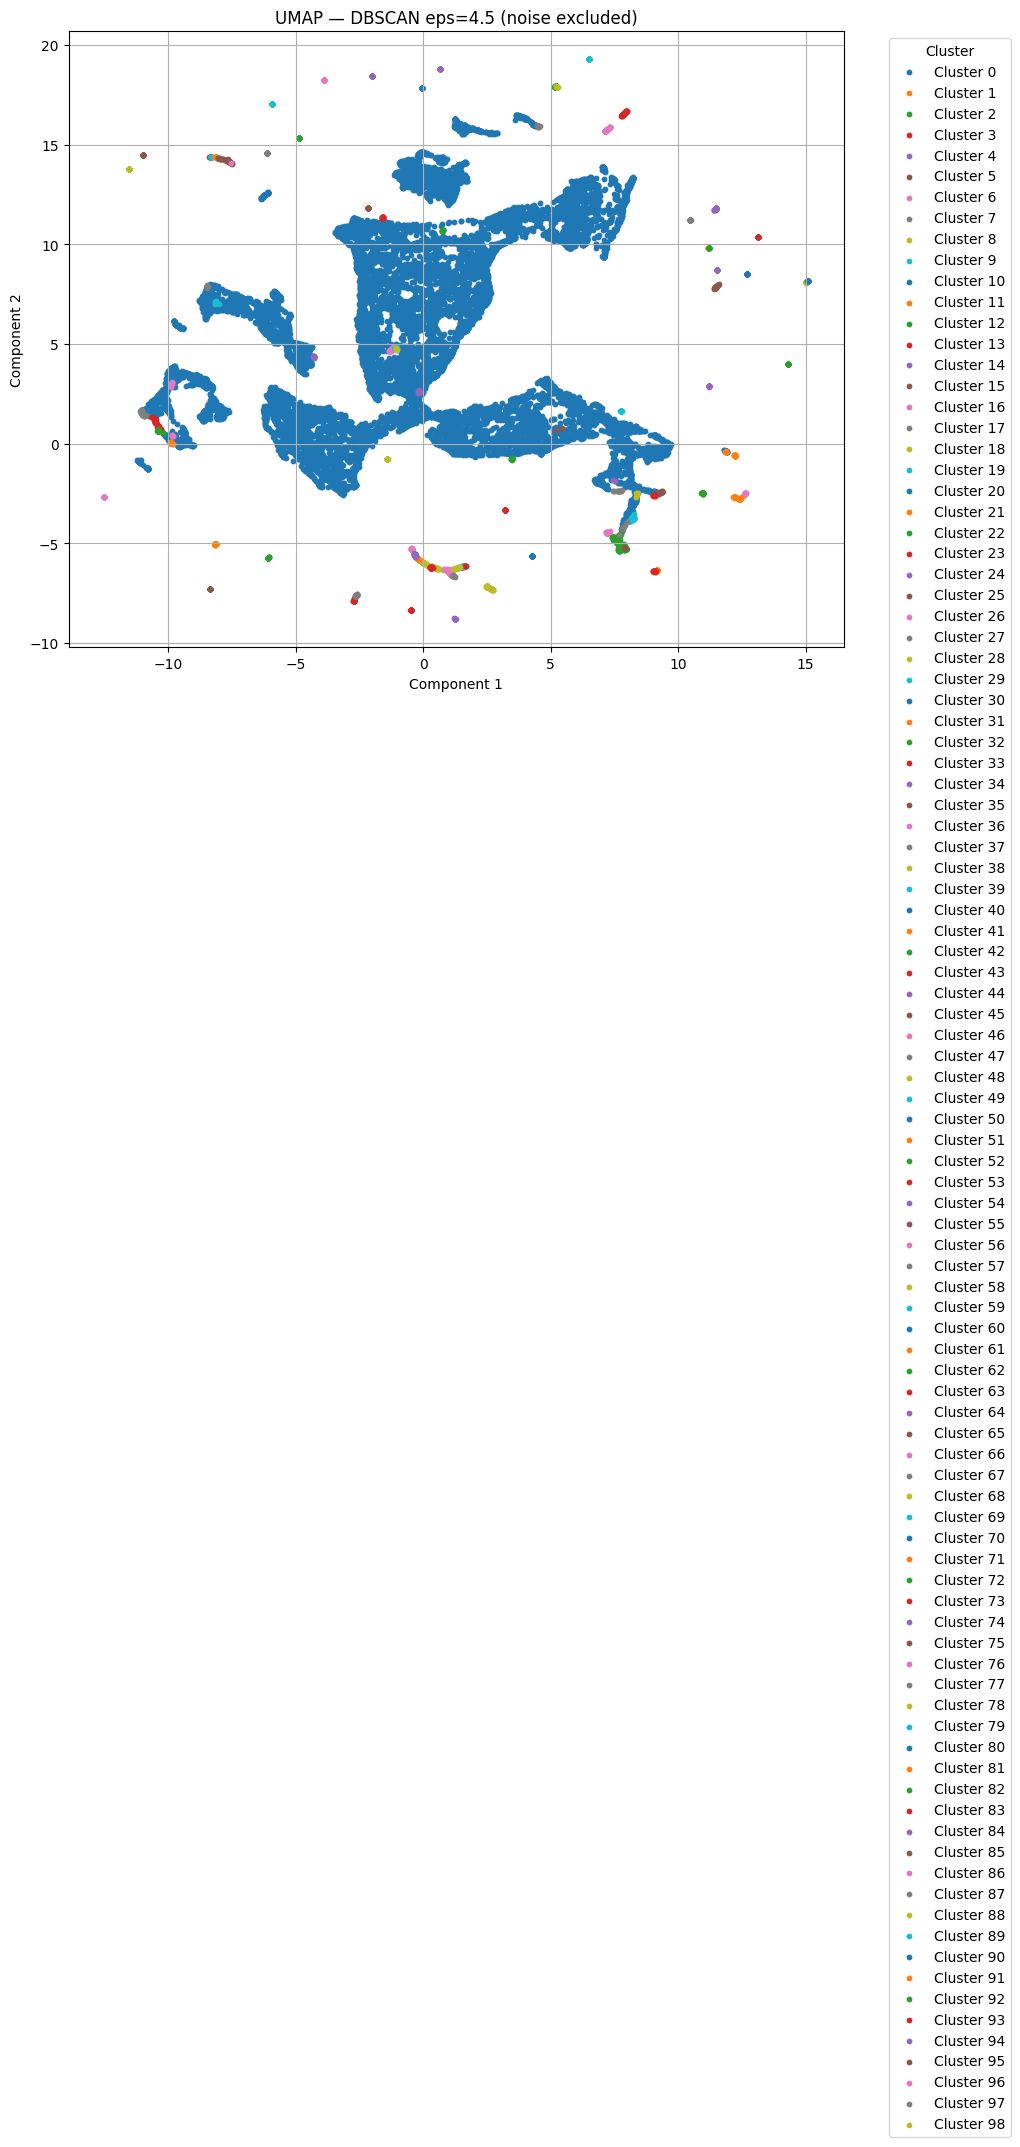

In [24]:
# Visualise non-noise points only
mask   = labels_db != -1
umap_db = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
emb_db  = umap_db.fit_transform(X_db.values[mask])

visualize_umap(emb_db, labels=labels_db[mask],
               title=f"UMAP — DBSCAN eps={best_eps} (noise excluded)")

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>9. Mean Shift</b></h3></div>

<div style="background-color:#F9FCFF; padding:16px; border-radius:10px;">Mean Shift locates cluster centres at density peaks and determines the number of clusters automatically from the data. We run it on a sample for speed.</div>

In [25]:
X_ms = info_clustering.drop(columns=EXCLUDED_COLS)

ms_results = clu.explore_meanshift(X_ms, quantile_range=np.arange(0.05, 0.35, 0.05),
                                    sample_size=5000, random_state=42)
ms_results

,quantile,bandwidth,n_clusters,silhouette
0,0.05,24.2271,16,0.2778
1,0.10,35.3441,1,NaN
2,0.15,45.0452,1,NaN
3,0.20,54.4026,1,NaN
4,0.25,63.3448,1,NaN
5,0.30,72.2411,1,NaN


In [26]:
best_q = ms_results.iloc[0]["quantile"]
labels_ms, score_ms, n_clusters_ms = run_meanshift(X_ms, quantile=best_q,
                                                     sample_size=5000, random_state=42)

print(f"Mean Shift quantile={best_q}: Silhouette = {score_ms:.4f} | Clusters = {n_clusters_ms}")
print(pd.Series(labels_ms).value_counts().sort_index())

  Estimated bandwidth (quantile=0.05): 24.2271
Mean Shift quantile=0.05: Silhouette = 0.2778 | Clusters = 16
0     1494
1      772
2      663
3      626
4      474
5      266
6      250
7      206
8      175
9       42
10      11
11      10
12       5
13       3
14       2
15       1
Name: count, dtype: int64


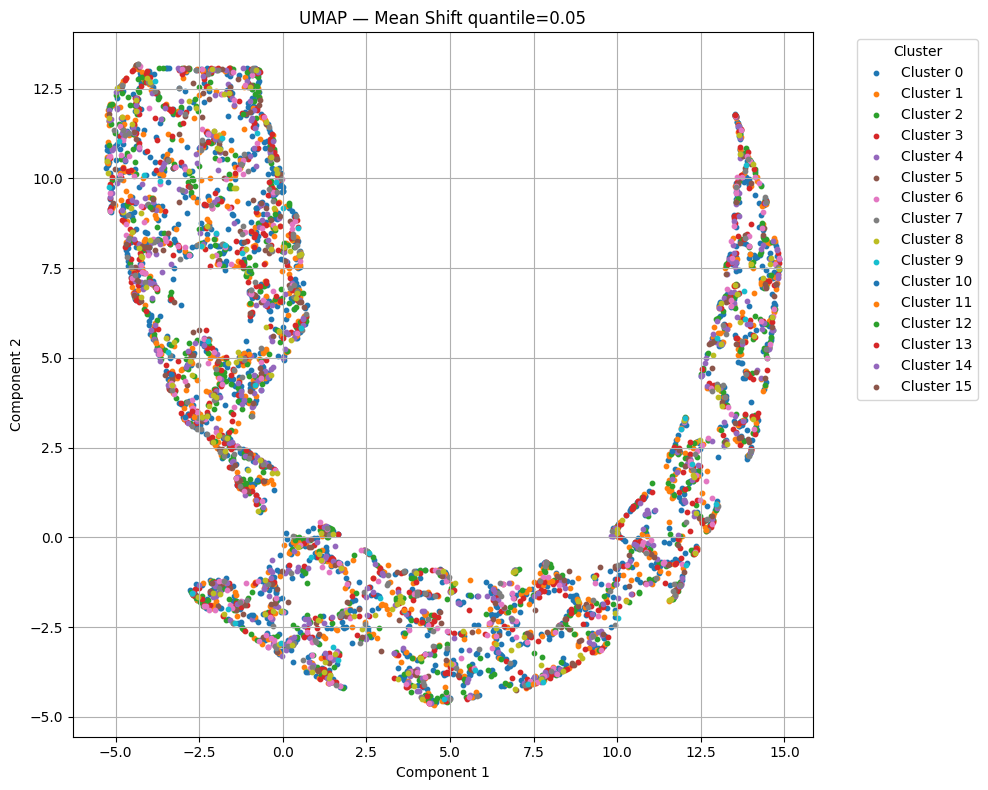

In [27]:
umap_ms = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
emb_ms  = umap_ms.fit_transform(X_ms.values[:len(labels_ms)])

visualize_umap(emb_ms, labels=labels_ms,
               title=f"UMAP — Mean Shift quantile={best_q}")

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>10. Model Comparison &amp; Final Choice</b></h3></div>

<div style="background-color:#F9FCFF; padding:16px; border-radius:10px;">Silhouette Score is the primary metric. We also consider cluster size balance and interpretability.</div>

In [28]:
from sklearn.metrics import silhouette_score as _sil

sil_km_final   = _sil(X_km_scaled,   labels_km,   sample_size=5000, random_state=42)
sil_hier_final = _sil(X_hier_scaled, labels_hier,  sample_size=5000, random_state=42)

comparison = compare_models({
    f"K-Means k={BEST_K} ({SCALER_KMEANS.capitalize()})":            sil_km_final,
    f"Hierarchical Ward k={BEST_K_HIER} ({SCALER_HIER.capitalize()})": sil_hier_final,
    f"DBSCAN eps={best_eps}":                                         score_db,
    f"Mean Shift q={best_q}":                                         score_ms,
})
display(comparison)

best_idx = comparison["Silhouette"].idxmax()
print(f"\nChosen model : {comparison.loc[best_idx, 'Model']}")
print(f"Silhouette   : {comparison.loc[best_idx, 'Silhouette']:.4f}")

,Model,Silhouette
0,Mean Shift q=0.05,0.2778
1,K-Means k=7 (Minmax),0.2160
2,Hierarchical Ward k=5 (Robust),0.0415
3,DBSCAN eps=4.5,-0.6609



Chosen model : Mean Shift q=0.05
Silhouette   : 0.2778


In [29]:
FINAL_MODEL  = f"K-Means k={BEST_K} ({SCALER_KMEANS.capitalize()})"
final_labels = labels_km
print(f"Final model: {FINAL_MODEL}")

Final model: K-Means k=7 (Minmax)


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>11. Assigning Outliers to the Final Model</b></h3></div>

<div style="background-color:#F9FCFF; padding:16px; border-radius:10px;">Customers removed during EDA outlier treatment are assigned to the nearest K-Means centroid using Euclidean distance, ensuring every customer has a cluster.</div>

In [30]:
outlier_dataset = read_outliers()
outlier_dataset.set_index("customer_id", inplace=True)

File not found: ../datasets/outlier_dataset.csv


KeyError: "None of ['customer_id'] are in the columns"

In [ ]:
# Align outlier columns to match the centroid feature columns exactly
outlier_X = outlier_dataset.reindex(columns=centroids_df_kmeans.columns, fill_value=0)

closest_idx, _ = pairwise_distances_argmin_min(
    X=outlier_X.values, Y=centroids_df_kmeans.values,
    metric="euclidean", axis=1)

outlier_dataset_final = outlier_dataset.copy()
outlier_dataset_final["kmeans_cluster"] = closest_idx

print("Outlier distribution across clusters:")
print(outlier_dataset_final["kmeans_cluster"].value_counts().sort_index())
display(outlier_dataset_final.head())

In [ ]:
dataset_cluster_final = pd.concat(
    [info_clustering_kmeans, outlier_dataset_final], axis=0)

print(f"Final dataset: {len(dataset_cluster_final):,} customers "
      f"({len(info_clustering_kmeans):,} regular + {len(outlier_dataset_final):,} outliers)")
print("\nFinal cluster distribution:")
print(dataset_cluster_final["kmeans_cluster"].value_counts().sort_index())

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;"><h3><b>12. Export</b></h3></div>

In [ ]:
#dataset_cluster_final.to_csv("../datasets/dataset_cluster_final.csv", index=True)
print("Uncomment the line above to save the final segmentation file.")